# Analysis

*Analysis now is preliminary and will most likely be adjusted and updated in light of new context.*

### Research Questions

**RQ1:** Does nine sessions of treadmill running over three weeks produce measurable cardiovascular adaptation, as reflected in heart rate response to a standardized interval treadmill session?
- **RQ1a:** Is the mean heart rate during a standardized treadmill session lower on the final training day compared to the first?
- **RQ1b:** Is the average inter-interval heart rate recovery greater on the final training day compared to the first?

**Explanation:**
If cardiovascular adaptation occurs, the heart should handle the same workload more efficiently over time. Two complementary metrics are used to capture this: one reflecting how hard the heart works during exercise, and one reflecting how quickly it recovers between efforts. (Heart rate variance is dropped because it does not add clear interpretative value in our project context.)

For RQ1a, since the running pace is identical on both days, a lower mean heart rate on Day 21 indicates that the heart is sustaining the same workload with less effort, the most direct sign of early aerobic adaptation.

For RQ2a, heart rate recovery is defined as the peak heart rate at the end of each run interval MINUS the heart rate one minute into the subsequent walk/jog period, averaged across the first four intervals. See [Heart Rate Recovery (HRR)](https://my.clevelandclinic.org/health/articles/23490-heart-rate-recovery). A larger value on Day 21 indicates the heart is decelerating faster between efforts, reflecting improved autonomic regulation.


### Individual and Group Analysis

**Individual analysis**
With only five participants, inspecting each person separately is possible and feasible. It lets us see the full HR trace at native/original granularity, spot device-specific quirks and/or irregularities, and judge data quality per person before drawing any group-level conclusions. Especially since we have different watches. 

**Group analysis**
The research question asks about cardiovascular adaptation in general, not for any one person. The paired t-test and effect size give a single formal answer to that question. 
    
**Why report both**
Individual plots show what is actually happening through (visual) data exploration; the group test draws the conclusion. 

**Why keep device-specific granularity**
For the plots, native resolution is kept because when available, high-resolution traces are genuinely more informative and degrading them loses real data. For the mean HR calculation, granularity does NOT affect the result. For HRR, low-granularity devices introduce uncertainty in peak detection, which should be explicitly noted (as a quality limitation) per participant rather than resolved by downsampling everyone to the worst case. 


In [237]:
# Regarding data quality    
# TODO: suspect 2 data seems fine, EXCEPT for one outlier run.
# TODO: suspect 3 data seems fine, EXCEPT for deciding whether to interpolate or not to ensure consistent measurements like the rest. 
# TODO: suspect 4 data seems NOT fine, BECAUSE it looks simply too random to draw valid conclusions from. 
# TODO: suspect 5 data seems fine, EXCEPT that two runs are misaligned, however this can be easily fixed by adjusting the timestamps
# TODO: suspect 6 seems NOT fine, BECAUSE the data has not been made granular, there are so little runs, the runs are not long enough

In [238]:
# Regarding decisions
# TODO: decision on adopting the new research questions
# TODO: decision on both individual analysis (visuals) and group analysis (formal testing) which can be justified based on the small group size
# TODO: decision to keep per-person granularity instead of downsampling/upsampling and justification
# TODO: decision on whether or not, and WHAT external factors to include in analysis

### Indvidual Analysis

The individual analysis is exploratory. It is to confirm the data, whether it looks okay, and whether alternative decisions need to be made on how the data is presented. 

In [239]:
# TODO: fix the per-week sessions (it is just consecutive rn, doesn't handle missing runs)
# TODO: rename suspect names from 2 to 6 to 1 to 5
# TODO: does it make more sense to 'smooth' everything over as that is likely the underlying 'real' function? nah, but for visualization can maybe show with savitzky-golay filter!

**Plot 1: HR trace across all sessions overlaid**

In [240]:
# Week colour palettes: light -> dark progression within each week
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime

WEEK_PALETTES = {
    1: ["#c6dbef", "#6baed6", "#2171b5"],  # blues
    2: ["#c7e9c0", "#74c476", "#238b45"],  # greens
    3: ["#fcbba1", "#fb6a4a", "#cb181d"],  # reds
}

# Hatch settings — colour-independent, pattern-based distinction
RUN_HATCH   = "////"   # forward diagonal for run
WALK_HATCH  = "\\\\"   # back diagonal for walk
HATCH_COLOR = "#aaaaaa"  # neutral mid-grey for all hatch lines


def get_session_colors(n_sessions: int) -> list:
    """
    Assign colours grouped by week (sessions 1-3 = week 1, 4-6 = week 2, 7-9 = week 3).
    Within each week, colours go light to dark to show progression.
    Handles fewer than 9 sessions gracefully.
    """
    colors = []
    for i in range(n_sessions):
        week = min(i // 3 + 1, 3)
        pos_in_week = i % 3
        colors.append(WEEK_PALETTES[week][pos_in_week])
    return colors


def build_interval_schedule(run_start_sec: float) -> list:
    """
    Build the fixed interval schedule starting from run_start_sec.
    Protocol: 70s run, 60s walk, 80s run, 60s walk, ..., 120s run, cool-down walk.
    Returns a list of dicts with keys: start, end, phase ('run' or 'walk').
    """
    run_durations = [70, 80, 90, 100, 110, 120]
    walk_duration = 60

    schedule = []
    cursor = run_start_sec

    for run_dur in run_durations:
        schedule.append({"start": cursor, "end": cursor + run_dur, "phase": "run"})
        cursor += run_dur
        schedule.append({"start": cursor, "end": cursor + walk_duration, "phase": "walk"})
        cursor += walk_duration

    return schedule


def plot_hr_all_sessions(
    json_path: str,
    run_start_sec: float,
    time_unit: str = "seconds",
    figsize: tuple = (14, 6),
    alpha_traces: float = 0.9,
    title: str = None,
):
    """
    Plot all HR sessions for one participant overlaid on a single axis.
    Run/walk intervals are distinguished by hatch patterns (no fill colour).
    Sessions are coloured light-to-dark within each week (week 1=blue, 2=green, 3=red).
    Legend is placed horizontally below the plot.

    Parameters
    ----------
    json_path      : path to suspect_#.json
    run_start_sec  : elapsed seconds from session start at which the first run interval begins
    time_unit      : "seconds" or "minutes" for the x-axis label
    figsize        : figure size tuple (slightly taller to accommodate bottom legend)
    alpha_traces   : transparency of individual session lines
    title          : optional plot title override
    """
    # ------------------------------------------------------------------ load
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs = data["runs"]

    # --------------------------------------------------------- interval bands
    schedule = build_interval_schedule(run_start_sec)

    # ------------------------------------------------------------------ plot
    fig, ax = plt.subplots(figsize=figsize)

    # Background hatch bands
    for interval in schedule:
        t0 = interval["start"] / 60 if time_unit == "minutes" else interval["start"]
        t1 = interval["end"]   / 60 if time_unit == "minutes" else interval["end"]
        hatch = RUN_HATCH if interval["phase"] == "run" else WALK_HATCH
        ax.axvspan(
            t0, t1,
            facecolor="none",
            edgecolor=HATCH_COLOR,
            hatch=hatch,
            alpha=0.4,
            linewidth=0,
            zorder=0,
        )

    # Grid
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    # HR traces
    session_colors = get_session_colors(len(runs))

    for idx, run in enumerate(runs):
        records = run["per_second_data"]
        if not records:
            continue

        t0_abs = datetime.fromisoformat(records[0]["timestamp"])
        times, hrs = [], []

        for rec in records:
            t_abs = datetime.fromisoformat(rec["timestamp"])
            elapsed = (t_abs - t0_abs).total_seconds()
            if time_unit == "minutes":
                elapsed /= 60
            times.append(elapsed)
            hrs.append(rec["heart_rate"])

        week = idx // 3 + 1
        pos  = idx % 3 + 1
        label = f"W{week} S{pos} ({run['run_id'].replace(f'{suspect_id}_run_', '')})"

        ax.plot(
            times, hrs,
            color=session_colors[idx],
            linewidth=1.3,
            alpha=alpha_traces,
            label=label,
        )

    # --------------------------------------------------------- legend (below plot)
    session_handles, session_labels = ax.get_legend_handles_labels()

    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    run_patch = mpatches.Patch(
        facecolor="white", edgecolor=HATCH_COLOR,
        hatch=RUN_HATCH, label="Run interval"
    )
    walk_patch = mpatches.Patch(
        facecolor="white", edgecolor=HATCH_COLOR,
        hatch=WALK_HATCH, label="Walk / recovery"
    )

    all_handles = session_handles + [mpatches.Patch(color="none", label="")] + week_patches + [run_patch, walk_patch]

    ax.legend(
        handles=all_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=7,
        fontsize=7.5,
        framealpha=0.7,
        borderaxespad=0,
    )

    xlabel = "Elapsed time (min)" if time_unit == "minutes" else "Elapsed time (s)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Heart Rate (bpm)")
    ax.set_title(title or f"Exercise Heart Rate — All Sessions Overlaid ({suspect_id})")
    ax.set_xlim(left=0)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)  # make room for the legend below
    plt.show()

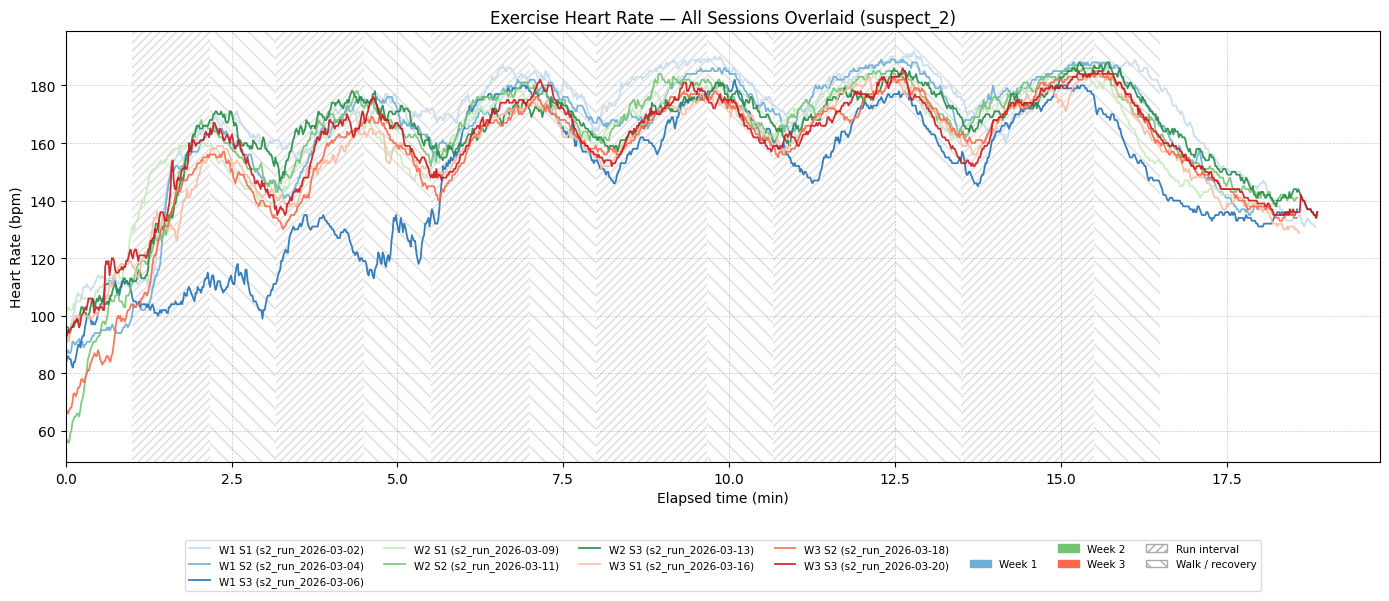

'The data points are highly granular (every second). Overall, the bumps and troughs are consistent. Generally, the last week (red lines) sit below the blue and green lines, which indicates that the heart rate does decrease over time. However, there seems to be one outlier run at the last run of week 1 (light blue) as the measurements seem much lower than normal at the start and are still lower than normal during the rest of the run.'

In [241]:
# Suspect 2
plot_hr_all_sessions(
    json_path="../processed/suspect_2.json",
    run_start_sec=60,        # adjust to where the first run interval starts for this person
    time_unit="minutes",     # or "minutes"
)

"The data points are highly granular (every second). Overall, the bumps and troughs are consistent. Generally, the last week (red lines) sit below the blue and green lines, which indicates that the heart rate does decrease over time. However, there seems to be one outlier run at the last run of week 1 (light blue) as the measurements seem much lower than normal at the start and are still lower than normal during the rest of the run."

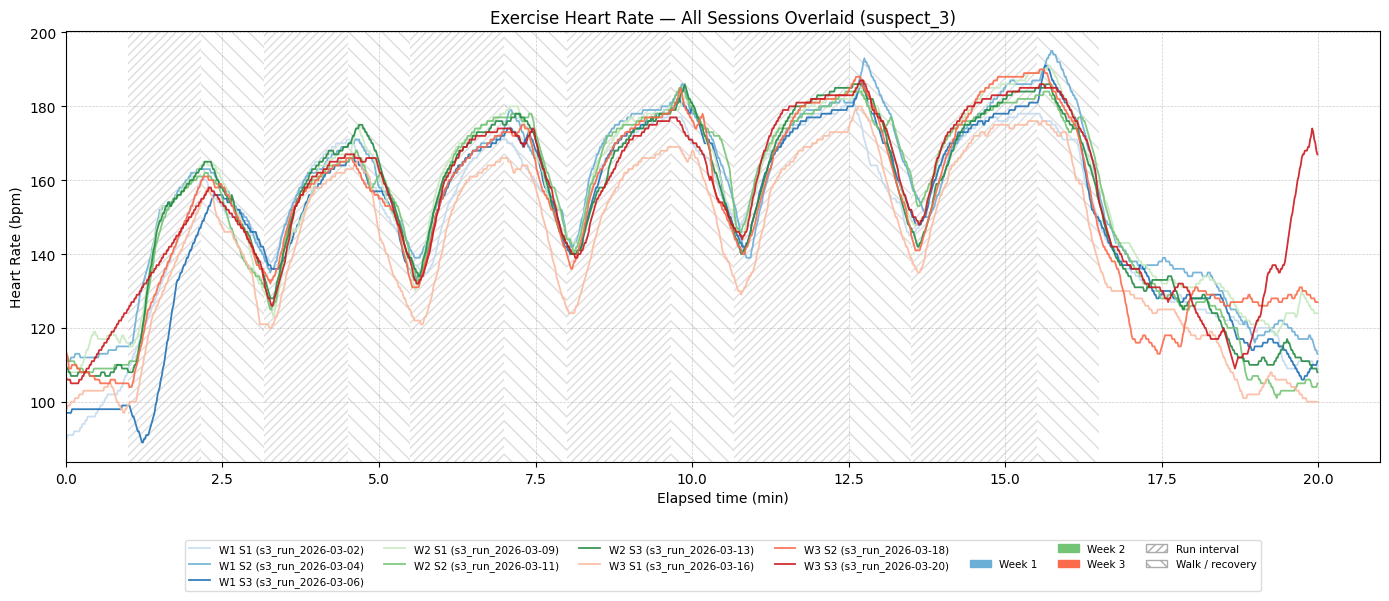

'The data points are granular (original data is every few seconds, but has been interpolated, so that it is every second). Overall, the bumps and troughs are consistent, except at the start: the long straight lines are due to filling caused by sparse measurements. Generally, there seem to be minimal changes in heart rates over the weeks. However, one run that is notably distinct is the last run, which seems to be consistently lower than all other runs.'

In [242]:
# Suspect 3
plot_hr_all_sessions(
    json_path="../processed/suspect_3.json",
    run_start_sec=60,        # adjust to where the first run interval starts for this person
    time_unit="minutes",     # or "minutes"
)

# TODO: compare with raw data instead of interpolating
# TODO: mention that one run was in the morning instead of evening; does this have an impact? 
"The data points are granular (original data is every few seconds, but has been interpolated, so that it is every second). Overall, the bumps and troughs are consistent, except at the start: the long straight lines are due to filling caused by sparse measurements. Generally, there seem to be minimal changes in heart rates over the weeks. However, one run that is notably distinct is the last run, which seems to be consistently lower than all other runs."

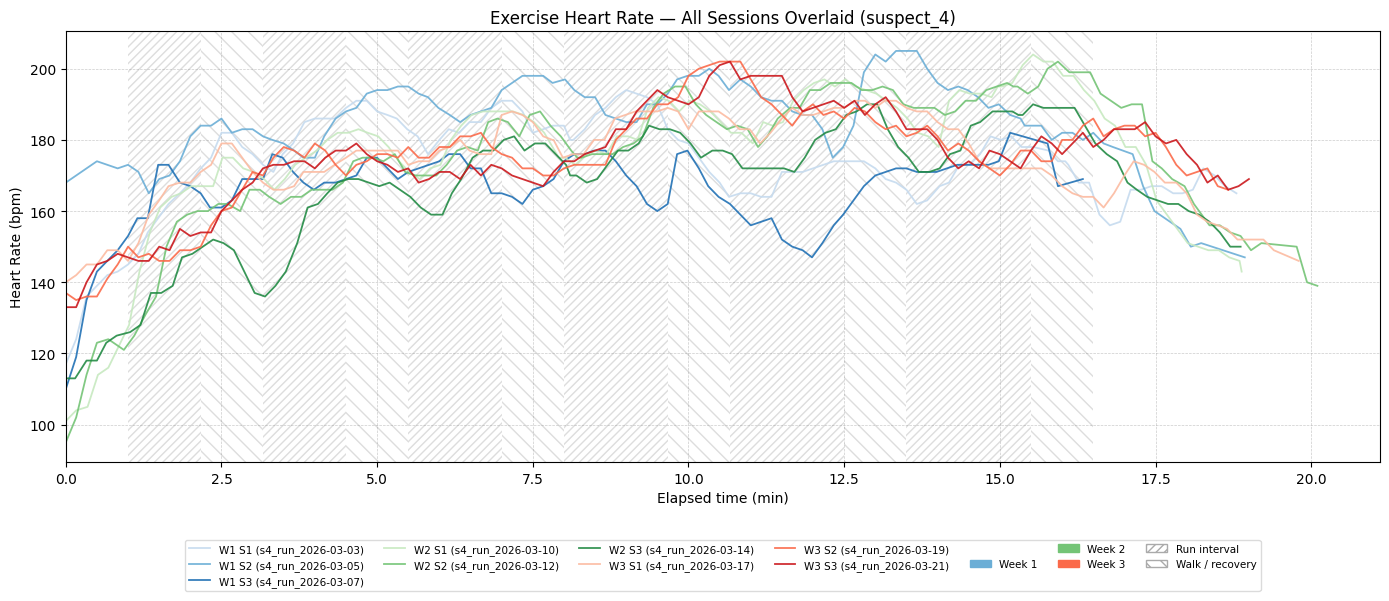

'The data points are moderately granular (every 10 seconds). Overall, the bumps and troughs are very inconsistent and the runs themselves do not seem to align. It is difficult to see upfront whether the heart rate drops or not as time goes on.'

In [243]:
# Suspect 4
plot_hr_all_sessions(
    json_path="../processed/suspect_4.json",
    run_start_sec=60,        # adjust to where the first run interval starts for this person
    time_unit="minutes",     # or "minutes"
)

# TODO: compare with raw data instead of interpolating
"The data points are moderately granular (every 10 seconds). Overall, the bumps and troughs are very inconsistent and the runs themselves do not seem to align. It is difficult to see upfront whether the heart rate drops or not as time goes on."

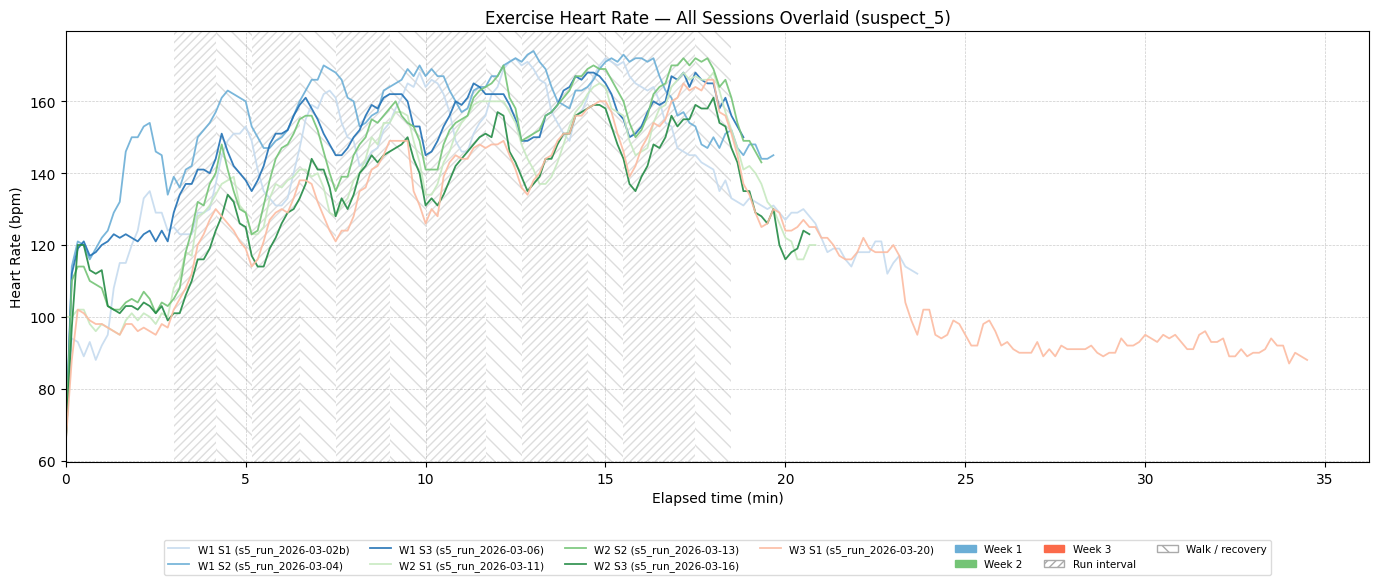

'The data points are moderately granular (original data is every minute, but has been upsampled to every 10 seconds with the help of AI). Overall, the bumps and troughs are rather consistent and the runs mostly align. It is very clear to see that the heart rate decreases as time goes on as each run falls below the previous runs. Some inconsistencies appear as some runs are recorded for quite long (red line). One or two runs appear to have been logged incorrectly (blue runs) as they are shifted to the front by one bump. Furthermore, only 7 runs are recorded such that 2 are missing.'

In [244]:
# Suspect 5
plot_hr_all_sessions(
    json_path="../processed/suspect_5.json",
    run_start_sec=180,        # adjust to where the first run interval starts for this person
    time_unit="minutes",     # or "minutes"
)

"The data points are moderately granular (original data is every minute, but has been upsampled to every 10 seconds with the help of AI). Overall, the bumps and troughs are rather consistent and the runs mostly align. It is very clear to see that the heart rate decreases as time goes on as each run falls below the previous runs. Some inconsistencies appear as some runs are recorded for quite long (red line). One or two runs appear to have been logged incorrectly (blue runs) as they are shifted to the front by one bump. Furthermore, only 7 runs are recorded such that 2 are missing."

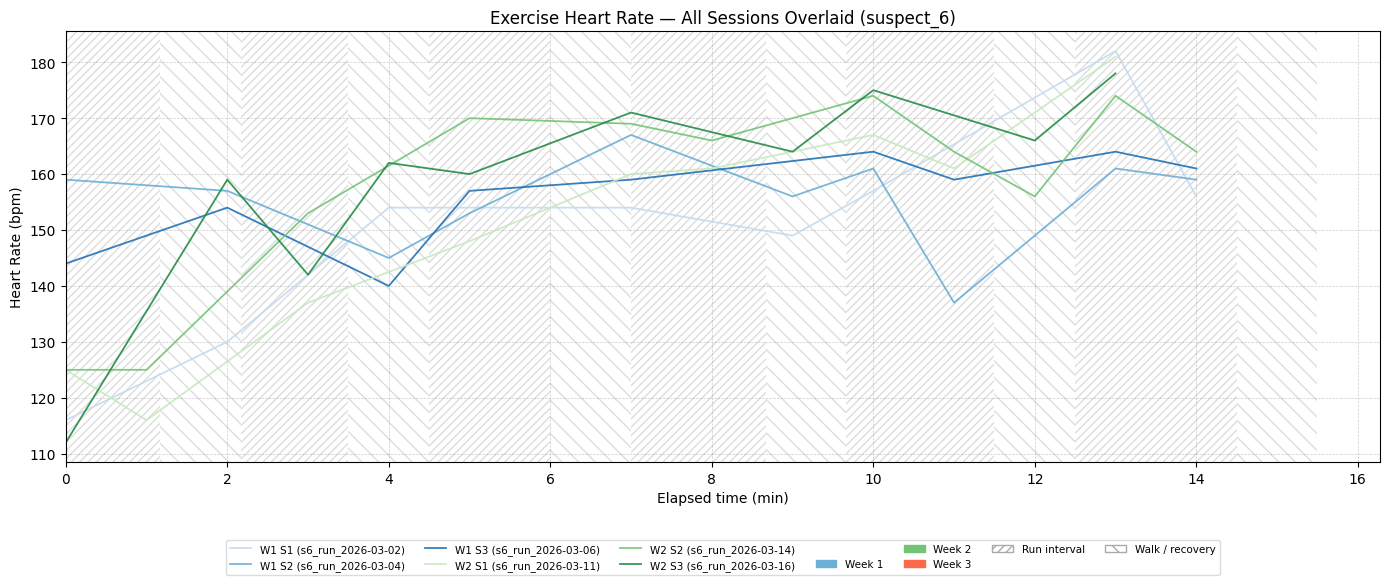

'The data points are mega super not granular (every minute). Perhaps the same AI process has to be applied to this since same problem as person above. Overall, the bumps and troughs are not consistent, although the runs do mostly align. It is not clear whether the heart rate decreases as time goes on. There are multiple problems with the data: the data does not appear to cover the full duration of the experiment (?!) and there are only 6 recorded runs (?!).'

In [245]:
# Suspect 6
plot_hr_all_sessions(
    json_path="../processed/suspect_6.json",
    run_start_sec=0,        # adjust to where the first run interval starts for this person
    time_unit="minutes",     # or "minutes"
)

"The data points are mega super not granular (every minute). Perhaps the same AI process has to be applied to this since same problem as person above. Overall, the bumps and troughs are not consistent, although the runs do mostly align. It is not clear whether the heart rate decreases as time goes on. There are multiple problems with the data: the data does not appear to cover the full duration of the experiment (?!) and there are only 6 recorded runs (?!)."

**Plot 2: Mean HR per session across all training days**

In [246]:
# TODO: the mean includes the walk periods. perhaps do the mean over only the run periods? 

In [247]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime


# Week colour palettes: light -> dark progression within each week
WEEK_PALETTES = {
    1: ["#c6dbef", "#6baed6", "#2171b5"],  # blues
    2: ["#c7e9c0", "#74c476", "#238b45"],  # greens
    3: ["#fcbba1", "#fb6a4a", "#cb181d"],  # reds
}

# Total protocol duration in seconds (from first run interval start to end of final cool-down)
# 6 runs: 70+80+90+100+110+120 = 570s
# 5 walk recoveries: 5x60 = 300s
# 1 final cool-down: 60s
# Total: 930s
PROTOCOL_DURATION_SEC = 930


def get_session_colors(n_sessions: int) -> list:
    colors = []
    for i in range(n_sessions):
        week = min(i // 3 + 1, 3)
        pos_in_week = i % 3
        colors.append(WEEK_PALETTES[week][pos_in_week])
    return colors


def compute_mean_hr_per_session(runs: list, run_start_sec: float) -> list:
    """
    For each session, compute mean HR over the protocol window only:
    from run_start_sec to run_start_sec + PROTOCOL_DURATION_SEC.

    Returns a list of dicts with keys: run_id, session_index, mean_hr (or None if no data).
    """
    results = []

    for idx, run in enumerate(runs):
        records = run["per_second_data"]
        if not records:
            results.append({"run_id": run["run_id"], "session_index": idx, "mean_hr": None})
            continue

        t0_abs = datetime.fromisoformat(records[0]["timestamp"])
        protocol_end_sec = run_start_sec + PROTOCOL_DURATION_SEC

        hrs_in_window = []
        for rec in records:
            t_abs = datetime.fromisoformat(rec["timestamp"])
            elapsed = (t_abs - t0_abs).total_seconds()
            if run_start_sec <= elapsed <= protocol_end_sec:
                hrs_in_window.append(rec["heart_rate"])

        mean_hr = np.mean(hrs_in_window) if hrs_in_window else None
        results.append({
            "run_id": run["run_id"],
            "session_index": idx,
            "mean_hr": mean_hr,
        })

    return results


def plot_mean_hr_per_session(
    json_path: str,
    run_start_sec: float,
    figsize: tuple = (9, 5),
    title: str = None,
):
    """
    Plot mean heart rate per session across all training days for one participant.
    Mean is computed over the protocol window only (run_start_sec to run_start_sec + 930s).
    Sessions are coloured by week (week 1=blue, week 2=green, week 3=red), light to dark.
    A linear trendline is fitted across all sessions.

    Parameters
    ----------
    json_path      : path to suspect_#.json
    run_start_sec  : elapsed seconds from recording start to first run interval
    figsize        : figure size tuple
    title          : optional plot title override
    """
    # ------------------------------------------------------------------ load
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs = data["runs"]

    # -------------------------------------------------------- compute means
    session_results = compute_mean_hr_per_session(runs, run_start_sec)

    session_indices = [r["session_index"] + 1 for r in session_results if r["mean_hr"] is not None]
    mean_hrs        = [r["mean_hr"]         for r in session_results if r["mean_hr"] is not None]
    colors          = get_session_colors(len(runs))
    point_colors    = [colors[r["session_index"]] for r in session_results if r["mean_hr"] is not None]

    # ------------------------------------------------------------------ plot
    fig, ax = plt.subplots(figsize=figsize)

    # Connecting line in neutral grey
    ax.plot(session_indices, mean_hrs, color="#aaaaaa", linewidth=1.2,
            linestyle="--", zorder=1)

    # Linear trendline
    x_arr = np.array(session_indices)
    y_arr = np.array(mean_hrs)
    slope, intercept = np.polyfit(x_arr, y_arr, 1)
    trend_x = np.linspace(x_arr.min(), x_arr.max(), 200)
    trend_y = slope * trend_x + intercept
    direction = "↓" if slope < 0 else "↑"
    ax.plot(
        trend_x, trend_y,
        color="#e07b39",
        linewidth=1,
        alpha=0.6,
        linestyle="-",
        zorder=2,
        label=f"Trend ({direction} {abs(slope):.2f} bpm/session)",
    )

    # Individual session dots coloured by week
    for x, y, c in zip(session_indices, mean_hrs, point_colors):
        ax.scatter(x, y, color=c, s=80, zorder=3, edgecolors="white", linewidths=0.6)

    # Annotate each point with its value
    for x, y in zip(session_indices, mean_hrs):
        ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.5)

    # Grid
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    # x-axis: session number with week label
    ax.set_xticks(range(1, len(runs) + 1))
    ax.set_xticklabels([
        f"S{i}\n(W{((i-1)//3)+1})" for i in range(1, len(runs) + 1)
    ], fontsize=8)

    # Legend — trendline + week colours, placed below plot
    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    trend_handle = mpatches.Patch(
        color="#e07b39",
        label=f"Trend ({direction} {abs(slope):.2f} bpm/session)"
    )

    ax.legend(
        handles=week_patches + [trend_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=4,
        fontsize=8,
        framealpha=0.7,
        borderaxespad=0,
    )

    ax.set_xlabel("Session")
    ax.set_ylabel("Mean Heart Rate (bpm)")
    ax.set_title(title or f"Mean HR per Session — Protocol Window Only ({suspect_id})")
    ax.set_xlim(0.5, len(runs) + 0.5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.20)
    plt.show()

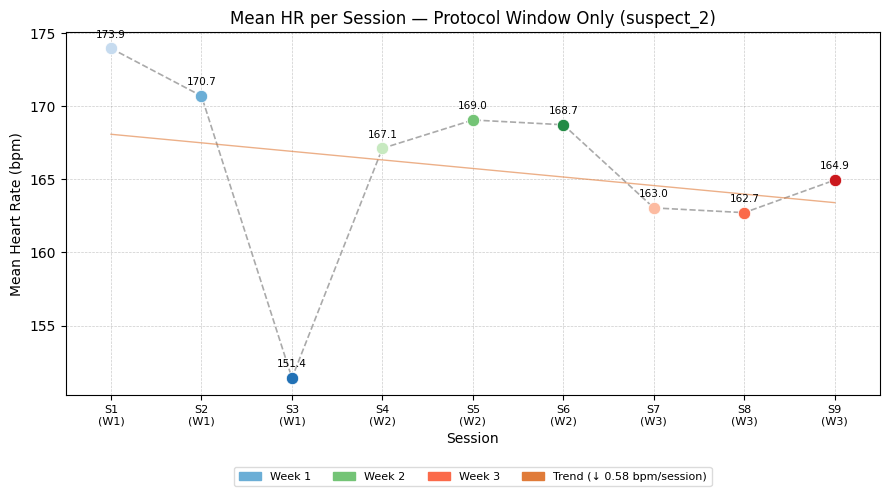

'Seems to go down slightly but consistently, except for a big outlier (third run). The question is whether to leave this run out or not.'

In [248]:
# Suspect 2
plot_mean_hr_per_session(
    json_path="../processed/suspect_2.json",
    run_start_sec=60,
)

"Seems to go down slightly but consistently, except for a big outlier (third run). The question is whether to leave this run out or not."

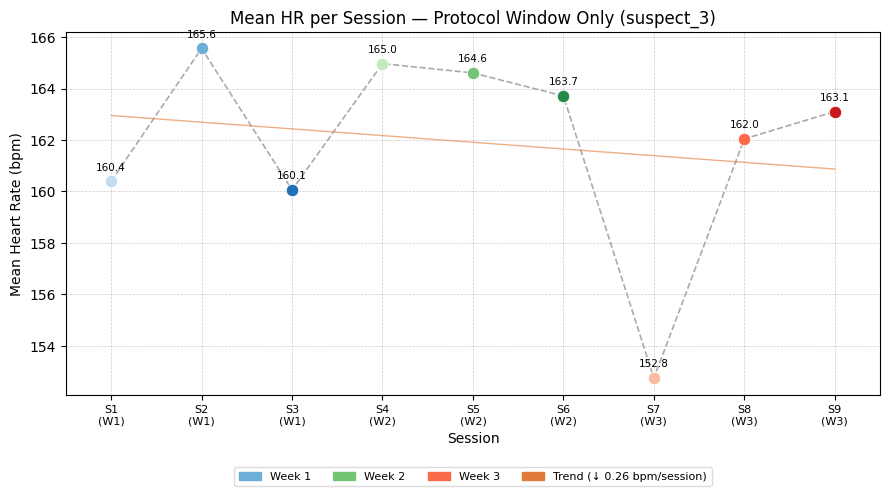

'Seems rather jumpy, not consistently going down. However, the trend line is still inching downwards, although that is possible due to a red outlier. Overall, however, the decrease is minimal (see y-axis scale). The first outlier (dark blue) can be explained because it was my first run and I planned to run 13 kmh, however, it proved to be too fast to me so I had to stop twice for a few seconds because I was too exhausted; this short rest may have lowered my heart rate. All consecutive runs are done at 12 kmh. The third light blue points can be more extreme perhaps because of the sparse and resulting low straight lines that draws the average down. Measuring only the remaining four points would have been more accurate likely but at the cost of less points.'

In [249]:
# Suspect 3
plot_mean_hr_per_session(
    json_path="../processed/suspect_3.json",
    run_start_sec=60,
)

"Seems rather jumpy, not consistently going down. However, the trend line is still inching downwards, although that is possible due to a red outlier. Overall, however, the decrease is minimal (see y-axis scale). The first outlier (dark blue) can be explained because it was my first run and I planned to run 13 kmh, however, it proved to be too fast to me so I had to stop twice for a few seconds because I was too exhausted; this short rest may have lowered my heart rate. All consecutive runs are done at 12 kmh. The third light blue points can be more extreme perhaps because of the sparse and resulting low straight lines that draws the average down. Measuring only the remaining four points would have been more accurate likely but at the cost of less points."

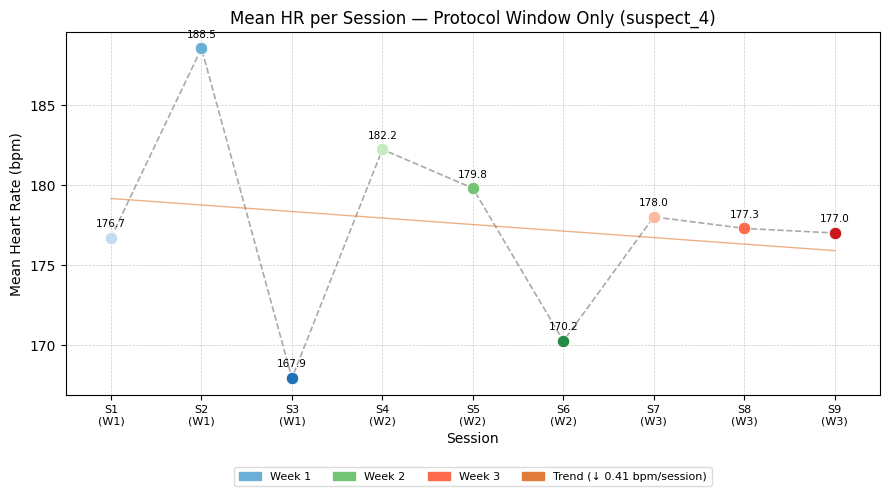

'Seems rather jumpy, but converging to the middle. Trend line is going down very slightly.'

In [250]:
# Suspect 4
plot_mean_hr_per_session(
    json_path="../processed/suspect_4.json",
    run_start_sec=60,
)

"Seems rather jumpy, but converging to the middle. Trend line is going down very slightly."

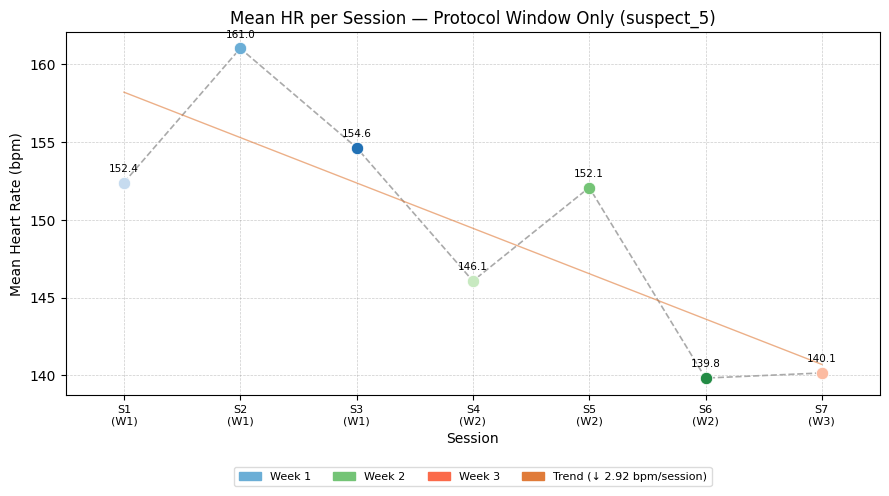

'While some fluctuations, the trend line is going down very steeply (ideal result).'

In [251]:
# Suspect 5
plot_mean_hr_per_session(
    json_path="../processed/suspect_5.json",
    run_start_sec=180,
)

"While some fluctuations, the trend line is going down very steeply (ideal result)."

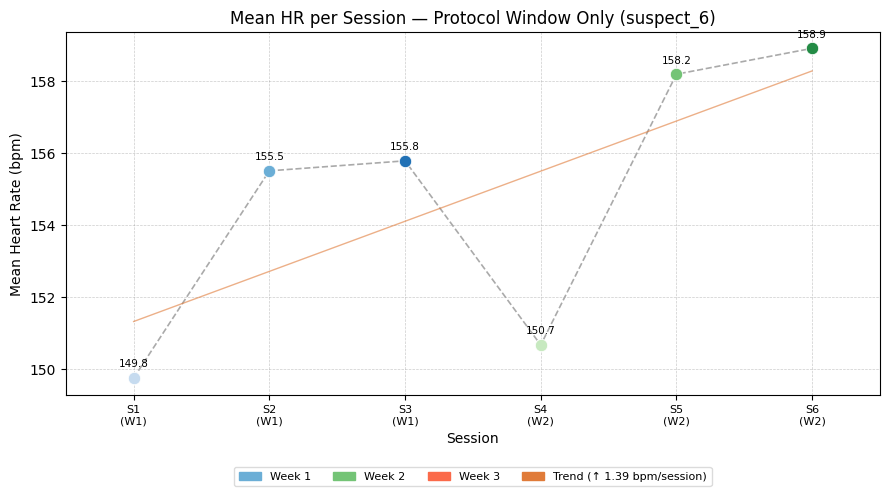

'The data points are going up (wat de helli). But again, the data points were flawed from the start.'

In [252]:
# Suspect 6
plot_mean_hr_per_session(
    json_path="../processed/suspect_6.json",
    run_start_sec=0,
)

"The data points are going up (wat de helli). But again, the data points were flawed from the start."

**Plot 3: Average inter-interval HRR per session across all training days**

In [253]:
# TODO: example HRR for one run
# TODO: then average inter-interval HRR for all

In [254]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime


# Week colour palettes: light -> dark progression within each week
WEEK_PALETTES = {
    1: ["#c6dbef", "#6baed6", "#2171b5"],  # blues
    2: ["#c7e9c0", "#74c476", "#238b45"],  # greens
    3: ["#fcbba1", "#fb6a4a", "#cb181d"],  # reds
}

# Hatch settings for run/walk background
RUN_HATCH   = "////"
WALK_HATCH  = "\\\\"
HATCH_COLOR = "#aaaaaa"

# Protocol definition
RUN_DURATIONS  = [70, 80, 90, 100, 110, 120]  # seconds per run interval
WALK_DURATION  = 60                             # seconds per walk recovery
N_HRR_INTERVALS = 6                            # total number of run intervals in protocol


def build_interval_schedule(run_start_sec: float) -> list:
    """Build the fixed interval schedule from run_start_sec."""
    schedule = []
    cursor = run_start_sec
    for run_dur in RUN_DURATIONS:
        schedule.append({"start": cursor, "end": cursor + run_dur, "phase": "run"})
        cursor += run_dur
        schedule.append({"start": cursor, "end": cursor + WALK_DURATION, "phase": "walk"})
        cursor += WALK_DURATION
    return schedule


def extract_hrr_per_interval(
    records: list,
    schedule: list,
    interval_range: tuple = (1, 6),
    window_sec: int = 10,
) -> list:
    """
    For each run->walk transition in interval_range (1-based, inclusive):
      - peak HR: maximum HR in [run_end - window_sec, run_end + window_sec]
                 straddling the boundary to account for cardiovascular lag
      - recovery HR:
          intervals 1-5: minimum HR in [run_end + 60 - window_sec, run_end + 60 + window_sec]
                         to avoid picking a rising value if the next run has already started
          interval 6:    single closest point to run_end + 60 (cool-down, no next run)
      - HRR: peak - recovery

    Parameters
    ----------
    records         : per_second_data list from JSON
    schedule        : output of build_interval_schedule()
    interval_range  : tuple (start, end), 1-based inclusive, e.g. (2, 6)
    window_sec      : seconds applied symmetrically around peak and recovery targets (default 10)

    Returns a list of dicts, one per included interval.
    """
    if not records:
        return []

    t0_abs = datetime.fromisoformat(records[0]["timestamp"])

    times, hrs = [], []
    for rec in records:
        t_abs = datetime.fromisoformat(rec["timestamp"])
        times.append((t_abs - t0_abs).total_seconds())
        hrs.append(rec["heart_rate"])

    times = np.array(times)
    hrs   = np.array(hrs)

    all_run_segs  = [s for s in schedule if s["phase"] == "run"]
    all_walk_segs = [s for s in schedule if s["phase"] == "walk"]

    # Total number of run intervals in the full protocol
    total_intervals = len(all_run_segs)

    # Convert 1-based interval_range to 0-based slice
    i_start = interval_range[0] - 1
    i_end   = interval_range[1]          # exclusive for slicing

    run_segs  = all_run_segs[i_start:i_end]
    walk_segs = all_walk_segs[i_start:i_end]

    results = []
    for interval_num, (run_seg, walk_seg) in enumerate(zip(run_segs, walk_segs), start=interval_range[0]):
        # Peak: max HR in symmetric window straddling run_end
        peak_mask = (
            (times >= run_seg["end"] - window_sec) &
            (times <= run_seg["end"] + window_sec)
        )
        if not np.any(peak_mask):
            results.append(None)
            continue
        peak_idx  = np.argmax(hrs[peak_mask])
        peak_hr   = hrs[peak_mask][peak_idx]
        peak_time = times[peak_mask][peak_idx]

        # Recovery: last interval uses exact point; all others use min in symmetric window
        target_time = run_seg["end"] + 60
        is_last     = (interval_num == total_intervals)

        if is_last:
            # Cool-down: no next run, so exact 60s point is reliable
            rec_idx  = np.argmin(np.abs(times - target_time))
            rec_hr   = hrs[rec_idx]
            rec_time = times[rec_idx]
        else:
            # Use minimum in window to avoid picking rising HR from next run start
            rec_mask = (
                (times >= target_time - window_sec) &
                (times <= target_time + window_sec)
            )
            if not np.any(rec_mask):
                rec_idx  = np.argmin(np.abs(times - target_time))
                rec_hr   = hrs[rec_idx]
                rec_time = times[rec_idx]
            else:
                rec_idx  = np.argmin(hrs[rec_mask])
                rec_hr   = hrs[rec_mask][rec_idx]
                rec_time = times[rec_mask][rec_idx]

        hrr = float(peak_hr) - float(rec_hr)
        results.append({
            "interval":      interval_num,
            "peak_hr":       float(peak_hr),
            "peak_time":     float(peak_time),
            "recovery_hr":   float(rec_hr),
            "recovery_time": float(rec_time),
            "hrr":           hrr,
        })

    return results


# =============================================================================
# FUNCTION 1 — HRR detail for a single session
# =============================================================================

def plot_hrr_single_session(
    json_path: str,
    run_start_sec: float,
    session_index: int = 0,
    interval_range: tuple = (1, 6),
    window_sec: int = 10,
    time_unit: str = "seconds",
    figsize: tuple = (14, 5),
    title: str = None,
):
    """
    Plot the HR trace for one session with HRR annotations for the specified intervals.
    Peak HR: max in [run_end - window_sec, run_end + window_sec].
    Recovery HR: min in [run_end + 60 - window_sec, run_end + 60 + window_sec]
                 except for the last interval where exact 60s point is used.

    Parameters
    ----------
    json_path       : path to suspect_#.json
    run_start_sec   : elapsed seconds from recording start to first run interval
    session_index   : 0-based index of the session to plot
    interval_range  : tuple (start, end), 1-based inclusive, e.g. (2, 6)
    window_sec      : symmetric window in seconds for peak and recovery search (default 10)
    time_unit       : "seconds" or "minutes"
    figsize         : figure size tuple
    title           : optional title override
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs       = data["runs"]

    if session_index >= len(runs):
        raise ValueError(f"session_index {session_index} out of range (only {len(runs)} sessions).")

    run     = runs[session_index]
    records = run["per_second_data"]
    schedule = build_interval_schedule(run_start_sec)

    # Build time/HR arrays
    t0_abs = datetime.fromisoformat(records[0]["timestamp"])
    times, hrs = [], []
    for rec in records:
        t_abs = datetime.fromisoformat(rec["timestamp"])
        elapsed = (t_abs - t0_abs).total_seconds()
        if time_unit == "minutes":
            elapsed /= 60
        times.append(elapsed)
        hrs.append(rec["heart_rate"])

    scale = 60 if time_unit == "minutes" else 1

    # Extract HRR values
    hrr_results = extract_hrr_per_interval(
        records, schedule,
        interval_range=interval_range,
        window_sec=window_sec,
    )

    # Week/session colour
    week        = session_index // 3 + 1
    pos         = session_index % 3
    trace_color = WEEK_PALETTES[min(week, 3)][pos]

    fig, ax = plt.subplots(figsize=figsize)

    # Background hatch
    for interval in schedule:
        t0 = interval["start"] / scale
        t1 = interval["end"]   / scale
        hatch = RUN_HATCH if interval["phase"] == "run" else WALK_HATCH
        ax.axvspan(t0, t1, facecolor="none", edgecolor=HATCH_COLOR,
                   hatch=hatch, alpha=0.4, linewidth=0, zorder=0)

    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    # HR trace
    ax.plot(times, hrs, color=trace_color, linewidth=1.4, zorder=2,
            label=f"HR trace — {run['run_id']}")

    # HRR annotations
    for hrr in hrr_results:
        if hrr is None:
            continue
        pt = hrr["peak_time"]    / scale
        rt = hrr["recovery_time"] / scale

        # Vertical drop line at peak_time x-position
        ax.vlines(
            x=pt,
            ymin=hrr["recovery_hr"],
            ymax=hrr["peak_hr"],
            color="#e07b39",
            linewidth=2,
            zorder=3,
        )
        # Peak dot
        ax.scatter(pt, hrr["peak_hr"],    color="#e07b39", s=55, zorder=4, edgecolors="white", linewidths=0.6)
        # Recovery dot (at 60s into walk)
        ax.scatter(rt, hrr["recovery_hr"], color="#e07b39", s=55, zorder=4, edgecolors="white", linewidths=0.6,
                   marker="D")

        # HRR label at midpoint of the drop line
        mid_y = (hrr["peak_hr"] + hrr["recovery_hr"]) / 2
        ax.annotate(
            f"HRR={hrr['hrr']:.0f}",
            xy=(pt, mid_y),
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=7.5,
            color="#e07b39",
            va="center",
        )

    # Legend
    peak_handle = plt.Line2D([], [], marker="o", color="#e07b39", linestyle="None",
                             markersize=6, label="Peak HR (end of run interval)")
    rec_handle  = plt.Line2D([], [], marker="D", color="#e07b39", linestyle="None",
                             markersize=6, label="Recovery HR (60s into walk)")
    drop_handle = plt.Line2D([], [], color="#e07b39", linewidth=2, label="HRR drop")
    run_patch   = mpatches.Patch(facecolor="none", edgecolor=HATCH_COLOR, hatch=RUN_HATCH,  label="Run interval")
    walk_patch  = mpatches.Patch(facecolor="none", edgecolor=HATCH_COLOR, hatch=WALK_HATCH, label="Walk / recovery")

    ax.legend(
        handles=[peak_handle, rec_handle, drop_handle, run_patch, walk_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=5,
        fontsize=7.5,
        framealpha=0.7,
        borderaxespad=0,
    )

    xlabel = "Elapsed time (min)" if time_unit == "minutes" else "Elapsed time (s)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Heart Rate (bpm)")
    week_label = session_index // 3 + 1
    ses_label  = session_index % 3 + 1
    ax.set_title(title or (
        f"HRR Detail — Session {session_index + 1} (W{week_label} S{ses_label}) "
        f"| {suspect_id}"
    ))
    ax.set_xlim(left=0)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.show()


# =============================================================================
# FUNCTION 2 — Average inter-interval HRR across all sessions
# =============================================================================
 
def get_session_colors(n_sessions: int) -> list:
    colors = []
    for i in range(n_sessions):
        week = min(i // 3 + 1, 3)
        pos_in_week = i % 3
        colors.append(WEEK_PALETTES[week][pos_in_week])
    return colors
 
 
def plot_hrr_all_sessions(
    json_path: str,
    run_start_sec: float,
    interval_range: tuple = (1, 6),
    window_sec: int = 10,
    figsize: tuple = (9, 5),
    title: str = None,
):
    """
    Plot average inter-interval HRR per session across all training days.
    HRR is computed per sprint interval and averaged across the included intervals.
    The shaded band shows the min and max HRR across the included intervals within
    each session, reflecting within-session recovery consistency.
    A linear trendline is fitted across sessions.
 
    Parameters
    ----------
    json_path       : path to suspect_#.json
    run_start_sec   : elapsed seconds from recording start to first run interval
    interval_range  : tuple (start, end), 1-based inclusive, e.g. (1, 6)
    window_sec      : symmetric window in seconds for peak and recovery search (default 10)
    figsize         : figure size tuple
    title           : optional title override
    """
    with open(json_path, "r") as f:
        data = json.load(f)
 
    suspect_id = data["suspect_id"]
    runs       = data["runs"]
    schedule   = build_interval_schedule(run_start_sec)
    colors     = get_session_colors(len(runs))
 
    session_nums, avg_hrrs, min_hrrs, max_hrrs, pt_colors = [], [], [], [], []
 
    for idx, run in enumerate(runs):
        hrr_results = extract_hrr_per_interval(
            run["per_second_data"], schedule,
            interval_range=interval_range,
            window_sec=window_sec,
        )
        hrr_vals = [h["hrr"] for h in hrr_results if h is not None]
        if not hrr_vals:
            continue
        session_nums.append(idx + 1)
        avg_hrrs.append(np.mean(hrr_vals))
        min_hrrs.append(np.min(hrr_vals))
        max_hrrs.append(np.max(hrr_vals))
        pt_colors.append(colors[idx])
 
    session_nums = np.array(session_nums)
    avg_hrrs     = np.array(avg_hrrs)
    min_hrrs     = np.array(min_hrrs)
    max_hrrs     = np.array(max_hrrs)
 
    fig, ax = plt.subplots(figsize=figsize)
 
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)
 
    n_intervals = interval_range[1] - interval_range[0] + 1
    band_label  = f"Min–Max range ({n_intervals} intervals)"
 
    # Shaded min-max band
    ax.fill_between(session_nums, min_hrrs, max_hrrs,
                    color="#e07b39", alpha=0.15, label=band_label)
 
    # Connecting line
    ax.plot(session_nums, avg_hrrs, color="#aaaaaa", linewidth=1.2, linestyle="--", zorder=1)
 
    # Trendline
    slope, intercept = np.polyfit(session_nums, avg_hrrs, 1)
    trend_x = np.linspace(session_nums.min(), session_nums.max(), 200)
    trend_y = slope * trend_x + intercept
    direction = "↑" if slope > 0 else "↓"
    ax.plot(trend_x, trend_y, color="#e07b39", linewidth=2, linestyle="-", zorder=2,
            label=f"Trend ({direction} {abs(slope):.2f} bpm/session)")
 
    # Session dots
    for x, y, c in zip(session_nums, avg_hrrs, pt_colors):
        ax.scatter(x, y, color=c, s=80, zorder=3, edgecolors="white", linewidths=0.6)
 
    # Value annotations
    for x, y in zip(session_nums, avg_hrrs):
        ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.5)
 
    # x-axis labels
    ax.set_xticks(range(1, len(runs) + 1))
    ax.set_xticklabels([
        f"S{i}\n(W{((i-1)//3)+1})" for i in range(1, len(runs) + 1)
    ], fontsize=8)
 
    # Legend
    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    trend_patch = mpatches.Patch(color="#e07b39",
                                 label=f"Trend ({direction} {abs(slope):.2f} bpm/session)")
    band_patch  = mpatches.Patch(color="#e07b39", alpha=0.3, label=band_label)
 
    ax.legend(
        handles=week_patches + [trend_patch, band_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=5,
        fontsize=8,
        framealpha=0.7,
        borderaxespad=0,
    )
 
    ax.set_xlabel("Session")
    ax.set_ylabel("Average HRR (bpm)")
    ax.set_title(title or f"Avg Inter-Interval HRR per Session ({suspect_id})")
    ax.set_xlim(0.5, len(runs) + 0.5)
 
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.show()

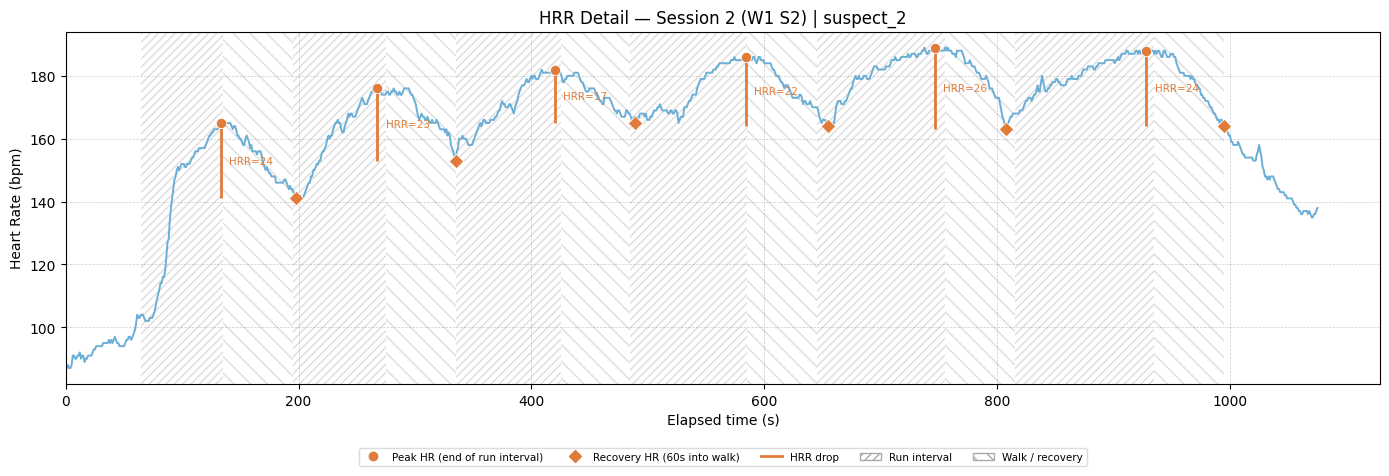

In [255]:
# Example for second run of suspect 2 how the HRR is calculated. 
# The peak and recovery are calculated in a 20 seconds interval surrounding the end of the run and the end of the recovery (60 seconds). 
plot_hrr_single_session("../processed/suspect_2.json", run_start_sec=65, session_index=1)

In [ ]:
# The average HRR over all sprints per session, for all sessions. The min and max range is obtained for each session. 

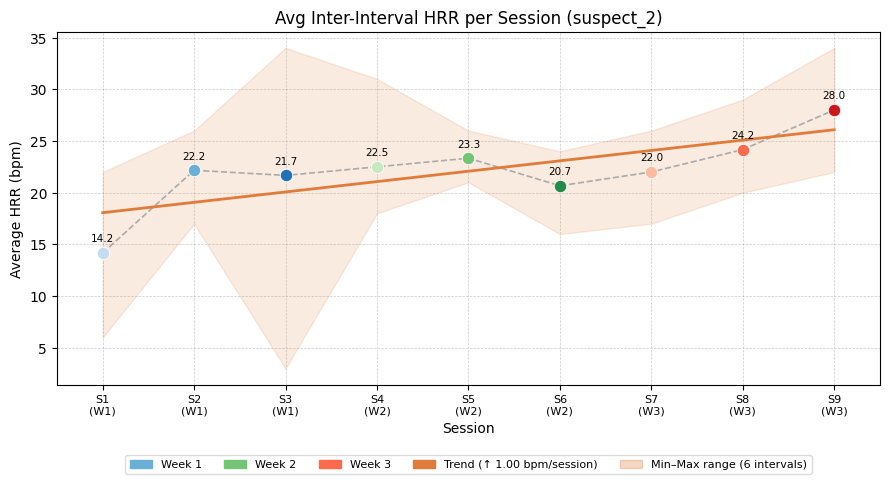

'The HRR is improving, which implies that the recovery is greater as the heart rate drops more after running.'

In [256]:
# Suspect 2
plot_hrr_all_sessions("../processed/suspect_2.json", run_start_sec=60)

"The HRR is improving, which implies that the recovery is greater as the heart rate drops more after running."

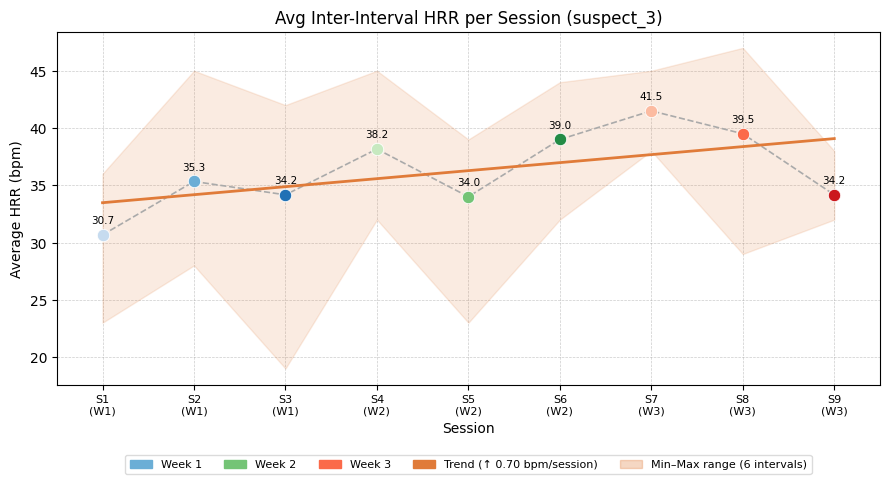

'Fluctuating and at the end even seems to go down. Again, the range is not as extreme as for example the person above.Overall, the trendline shows  slight increase.'

In [257]:
# Suspect 3
plot_hrr_all_sessions("../processed/suspect_3.json", run_start_sec=60)

"Fluctuating and at the end even seems to go down. Again, the range is not as extreme as for example the person above.Overall, the trendline shows  slight increase."

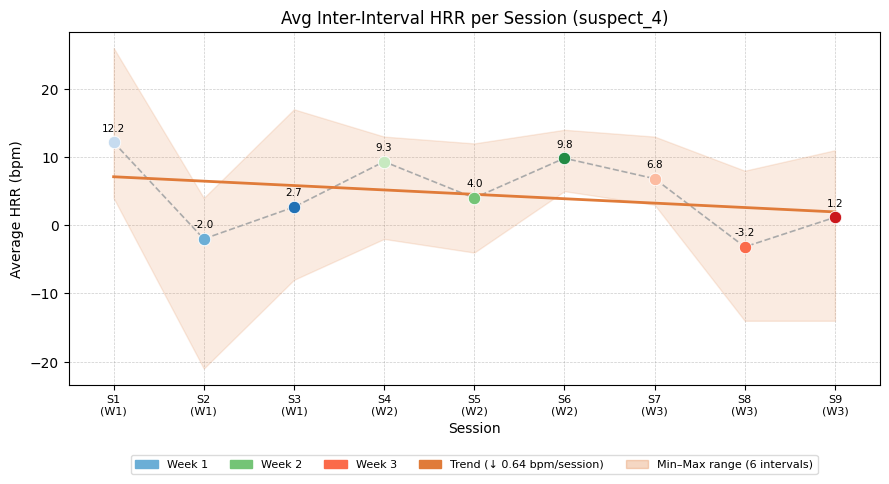

'Fluctuating and seems random.'

In [258]:
# Suspect 4
plot_hrr_all_sessions("../processed/suspect_4.json", run_start_sec=60)

"Fluctuating and seems random."

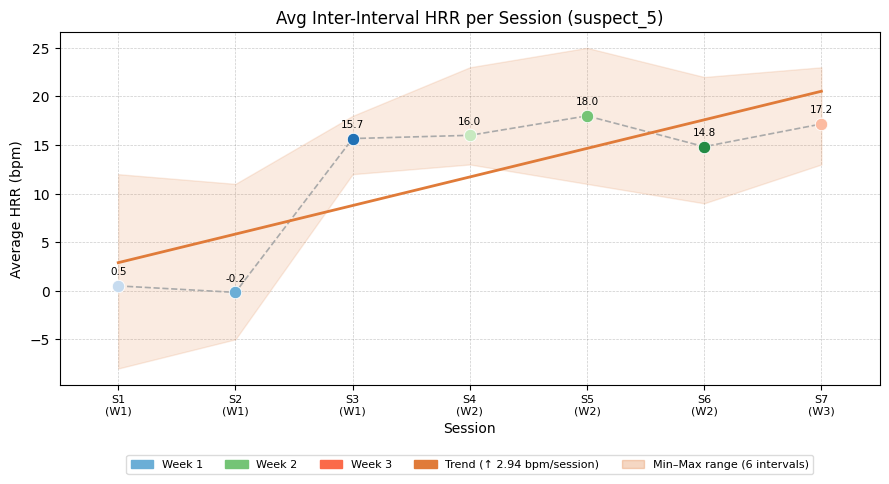

'Sharp increase. Good!'

In [259]:
# Suspect 5
plot_hrr_all_sessions("../processed/suspect_5.json", run_start_sec=180)

"Sharp increase. Good!"

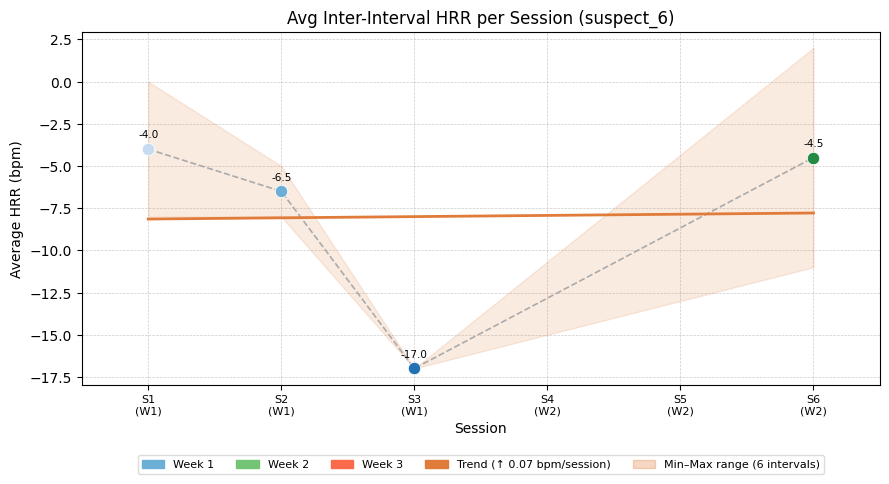

'Also completely random and too little data points.'

In [260]:
# Suspect 6
plot_hrr_all_sessions("../processed/suspect_6.json", run_start_sec=180)

"Also completely random and too little data points."

**Plot 4: Side-by-side HR trace for first day and last only**


In [261]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
from datetime import datetime


# ── shared constants (keep consistent with other plot files) ──────────────────
WEEK_PALETTES = {
    1: ["#c6dbef", "#6baed6", "#2171b5"],
    2: ["#c7e9c0", "#74c476", "#238b45"],
    3: ["#fcbba1", "#fb6a4a", "#cb181d"],
}
RUN_HATCH    = "////"
WALK_HATCH   = "\\\\"
HATCH_COLOR  = "#aaaaaa"
RUN_DURATIONS = [70, 80, 90, 100, 110, 120]
WALK_DURATION = 60

COLOR_FIRST  = "#2171b5"   # dark blue  — first session
COLOR_LAST   = "#cb181d"   # dark red   — last session
COLOR_MEAN   = "#e07b39"   # orange     — mean HR line
COLOR_DIFF   = "#888888"   # grey       — difference shading


def build_interval_schedule(run_start_sec: float) -> list:
    schedule, cursor = [], run_start_sec
    for run_dur in RUN_DURATIONS:
        schedule.append({"start": cursor, "end": cursor + run_dur, "phase": "run"})
        cursor += run_dur
        schedule.append({"start": cursor, "end": cursor + WALK_DURATION, "phase": "walk"})
        cursor += WALK_DURATION
    return schedule


def _parse_records(records: list, run_start_sec: float, time_unit: str):
    """Convert per_second_data to elapsed-time arrays, trimmed to protocol start."""
    t0_abs = datetime.fromisoformat(records[0]["timestamp"])
    scale  = 60 if time_unit == "minutes" else 1
    times, hrs = [], []
    for rec in records:
        t_abs   = datetime.fromisoformat(rec["timestamp"])
        elapsed = (t_abs - t0_abs).total_seconds()
        times.append(elapsed / scale)
        hrs.append(rec["heart_rate"])
    return np.array(times), np.array(hrs)


def _draw_background(ax, schedule, time_unit):
    scale = 60 if time_unit == "minutes" else 1
    for seg in schedule:
        t0    = seg["start"] / scale
        t1    = seg["end"]   / scale
        hatch = RUN_HATCH if seg["phase"] == "run" else WALK_HATCH
        ax.axvspan(t0, t1, facecolor="none", edgecolor=HATCH_COLOR,
                   hatch=hatch, alpha=0.35, linewidth=0, zorder=0)


def _draw_grid(ax):
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)


def _rolling_mean(hrs: np.ndarray, window: int = 15) -> np.ndarray:
    """Simple rolling mean to show the smoothed trend within a session."""
    kernel = np.ones(window) / window
    return np.convolve(hrs, kernel, mode="same")


def plot_first_vs_last(
    json_path: str,
    run_start_sec: float,
    window_sec: int = 10,
    time_unit: str = "seconds",
    rolling_window: int = 15,
    figsize: tuple = (14, 6),
    title: str = None,
):
    """
    Side-by-side (overlaid) HR trace for the first and last training session.
    Additional visuals included:
      - Rolling mean lines (smoothed trend) for each session
      - Shaded difference region between the two traces (resampled to common grid)
      - Horizontal dashed lines for session mean HR
      - Per-interval mean HR annotations (vertical bracket midpoint labels)
      - Run/walk background hatching

    Parameters
    ----------
    json_path       : path to suspect_#.json
    run_start_sec   : elapsed seconds from recording start to first run interval
    window_sec      : symmetric window for peak/recovery annotations (default 10)
    time_unit       : "seconds" or "minutes"
    rolling_window  : number of samples for rolling mean smoothing (default 15)
    figsize         : figure size tuple
    title           : optional title override
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs       = data["runs"]

    if len(runs) < 2:
        raise ValueError("Need at least 2 sessions to compare first and last.")

    first_run = runs[0]
    last_run  = runs[-1]
    schedule  = build_interval_schedule(run_start_sec)
    scale     = 60 if time_unit == "minutes" else 1

    t_first, hr_first = _parse_records(first_run["per_second_data"], run_start_sec, time_unit)
    t_last,  hr_last  = _parse_records(last_run["per_second_data"],  run_start_sec, time_unit)

    # Protocol window bounds
    protocol_end = (run_start_sec + sum(RUN_DURATIONS) + WALK_DURATION * len(RUN_DURATIONS)) / scale
    run_start    = run_start_sec / scale

    # Mask to protocol window only
    mask_first = (t_first >= run_start) & (t_first <= protocol_end)
    mask_last  = (t_last  >= run_start) & (t_last  <= protocol_end)

    # ── mean HR per session (protocol window) ────────────────────────────────
    mean_first = np.mean(hr_first[mask_first]) if np.any(mask_first) else np.nan
    mean_last  = np.mean(hr_last[mask_last])   if np.any(mask_last)  else np.nan

    # ── rolling means ────────────────────────────────────────────────────────
    roll_first = _rolling_mean(hr_first, rolling_window)
    roll_last  = _rolling_mean(hr_last,  rolling_window)

    # ── difference shading (resample last onto first time grid) ──────────────
    common_t    = np.linspace(
        max(t_first[mask_first].min(), t_last[mask_last].min()),
        min(t_first[mask_first].max(), t_last[mask_last].max()),
        500,
    )
    hr_first_interp = np.interp(common_t, t_first, hr_first)
    hr_last_interp  = np.interp(common_t, t_last,  hr_last)

    # ── figure ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    _draw_background(ax, schedule, time_unit)
    _draw_grid(ax)

    # Difference shading
    ax.fill_between(
        common_t,
        hr_first_interp,
        hr_last_interp,
        where=(hr_last_interp < hr_first_interp),
        interpolate=True,
        color=COLOR_LAST,
        alpha=0.10,
        label="Last < First (improvement)",
        zorder=1,
    )
    ax.fill_between(
        common_t,
        hr_first_interp,
        hr_last_interp,
        where=(hr_last_interp >= hr_first_interp),
        interpolate=True,
        color=COLOR_FIRST,
        alpha=0.10,
        label="Last ≥ First (no improvement)",
        zorder=1,
    )

    # Raw traces (faint)
    ax.plot(t_first, hr_first, color=COLOR_FIRST, linewidth=0.8, alpha=0.35, zorder=2)
    ax.plot(t_last,  hr_last,  color=COLOR_LAST,  linewidth=0.8, alpha=0.35, zorder=2)

    # Rolling mean traces (bold)
    ax.plot(t_first, roll_first, color=COLOR_FIRST, linewidth=2.0, alpha=0.9, zorder=3,
            label=f"Session 1 — smoothed (mean {mean_first:.1f} bpm)")
    ax.plot(t_last,  roll_last,  color=COLOR_LAST,  linewidth=2.0, alpha=0.9, zorder=3,
            label=f"Session {len(runs)} — smoothed (mean {mean_last:.1f} bpm)")

    # Horizontal mean HR lines
    ax.axhline(mean_first, color=COLOR_FIRST, linewidth=1.0, linestyle=":",
               alpha=0.7, zorder=2)
    ax.axhline(mean_last,  color=COLOR_LAST,  linewidth=1.0, linestyle=":",
               alpha=0.7, zorder=2)

    # Annotate mean lines on the right margin
    x_right = t_first.max() * 1.01
    ax.annotate(f"S1 mean\n{mean_first:.1f} bpm", xy=(x_right, mean_first),
                fontsize=7, color=COLOR_FIRST, va="center")
    ax.annotate(f"S{len(runs)} mean\n{mean_last:.1f} bpm", xy=(x_right, mean_last),
                fontsize=7, color=COLOR_LAST, va="center")

    # Per-interval mean HR labels — run phase + following 60s walk (capped at 60s for all)
    run_segs  = [s for s in schedule if s["phase"] == "run"]
    walk_segs = [s for s in schedule if s["phase"] == "walk"]
    for i, (seg, walk_seg) in enumerate(zip(run_segs, walk_segs)):
        t_mid = ((seg["start"] + seg["end"]) / 2) / scale

        # Window: run start to run end + 60s (includes the walk recovery, capped at 60s)
        interval_end = seg["end"] + 60

        seg_mask_f = (t_first >= seg["start"] / scale) & (t_first <= interval_end / scale)
        seg_mask_l = (t_last  >= seg["start"] / scale) & (t_last  <= interval_end / scale)

        if np.any(seg_mask_f) and np.any(seg_mask_l):
            m_f   = np.mean(hr_first[seg_mask_f])
            m_l   = np.mean(hr_last[seg_mask_l])
            y_bot = min(hr_first[seg_mask_f].min(), hr_last[seg_mask_l].min()) - 4

            ax.annotate(
                f"I{i+1}\nS1:{m_f:.0f}\nS{len(runs)}:{m_l:.0f}",
                xy=(t_mid, y_bot),
                ha="center", va="top", fontsize=6.5, color="#555555",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="#cccccc", alpha=0.7),
            )

    # ── legend ───────────────────────────────────────────────────────────────
    first_line  = mlines.Line2D([], [], color=COLOR_FIRST, linewidth=2,
                                label=f"Session 1 — smoothed (mean {mean_first:.1f} bpm)")
    last_line   = mlines.Line2D([], [], color=COLOR_LAST,  linewidth=2,
                                label=f"Session {len(runs)} — smoothed (mean {mean_last:.1f} bpm)")
    impr_patch  = mpatches.Patch(color=COLOR_LAST,  alpha=0.3, label="Last < First (improvement)")
    noimpr_patch= mpatches.Patch(color=COLOR_FIRST, alpha=0.3, label="Last ≥ First")
    run_patch   = mpatches.Patch(facecolor="none", edgecolor=HATCH_COLOR,
                                 hatch=RUN_HATCH,  label="Run interval")
    walk_patch  = mpatches.Patch(facecolor="none", edgecolor=HATCH_COLOR,
                                 hatch=WALK_HATCH, label="Walk / recovery")

    ax.legend(
        handles=[first_line, last_line, impr_patch, noimpr_patch, run_patch, walk_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=3,
        fontsize=7.5,
        framealpha=0.7,
        borderaxespad=0,
    )

    xlabel = "Elapsed time (min)" if time_unit == "minutes" else "Elapsed time (s)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Heart Rate (bpm)")
    ax.set_title(title or (
        f"First vs Last Session HR Trace ({suspect_id}) — "
        f"Session 1 vs Session {len(runs)}"
    ))
    ax.set_xlim(left=0)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18, right=0.93)
    plt.show()

In [262]:
# The red areas indicate improvement (the last run falls below the first run), the blue areas indicate the opposite. The sprint labels are calculated as the mean for that specific sprint including the 60 second cooldown. The global mean is given at the end over the entire session.

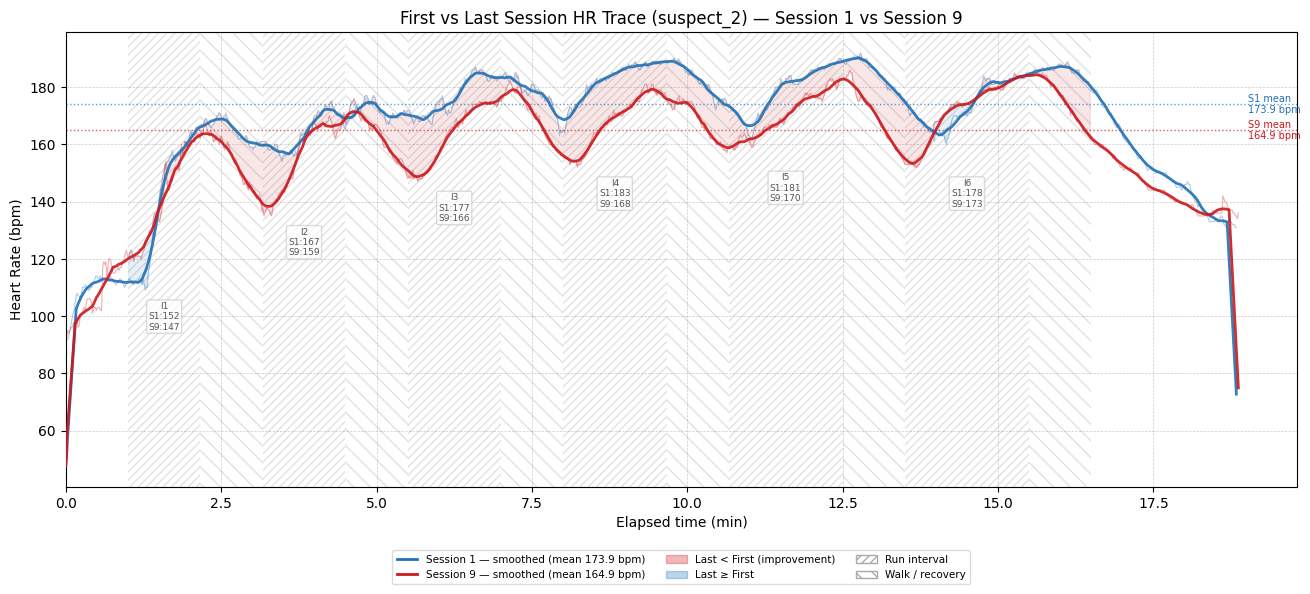

'The last run is lower than the first run. Indicates improvement.'

In [263]:
# Suspect 2
plot_first_vs_last("../processed/suspect_2.json", run_start_sec=60, time_unit="minutes", rolling_window=20)

"The last run is lower than the first run. Indicates improvement."

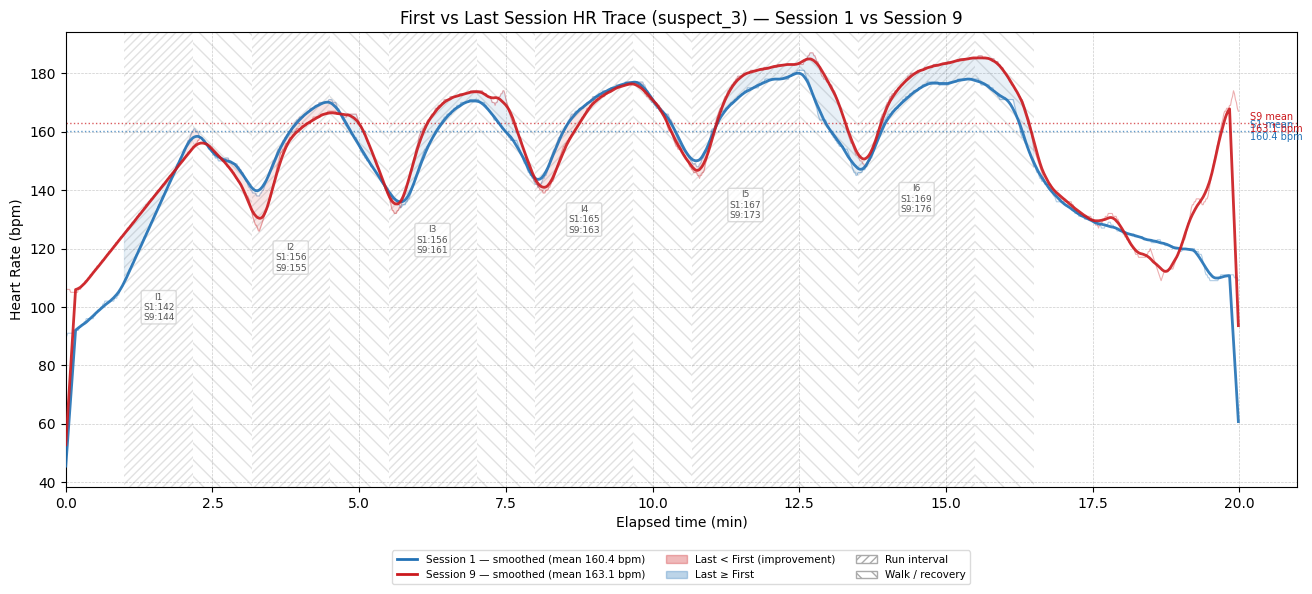

'The last and first run are nearly identical. Indicates no clear improvement.'

In [264]:
# Suspect 3
plot_first_vs_last("../processed/suspect_3.json", run_start_sec=60, time_unit="minutes", rolling_window=20)

"The last and first run are nearly identical. Indicates no clear improvement."

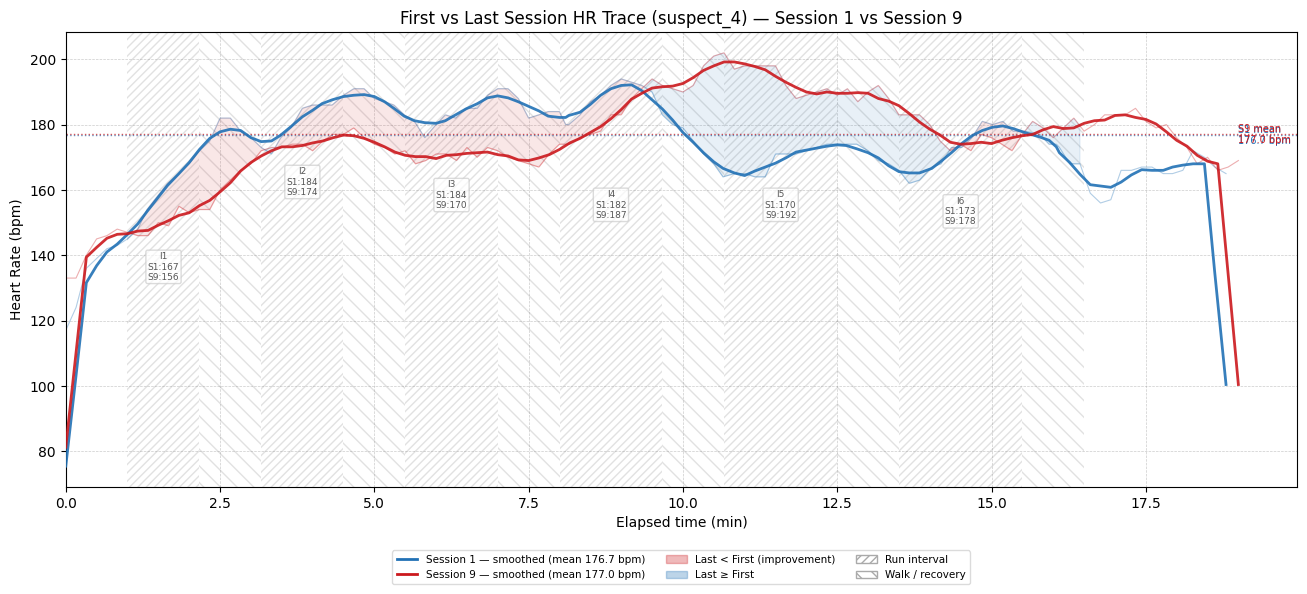

'Random.'

In [265]:
# Suspect 4 
plot_first_vs_last("../processed/suspect_4.json", run_start_sec=60, time_unit="minutes", rolling_window=5)

"Random."

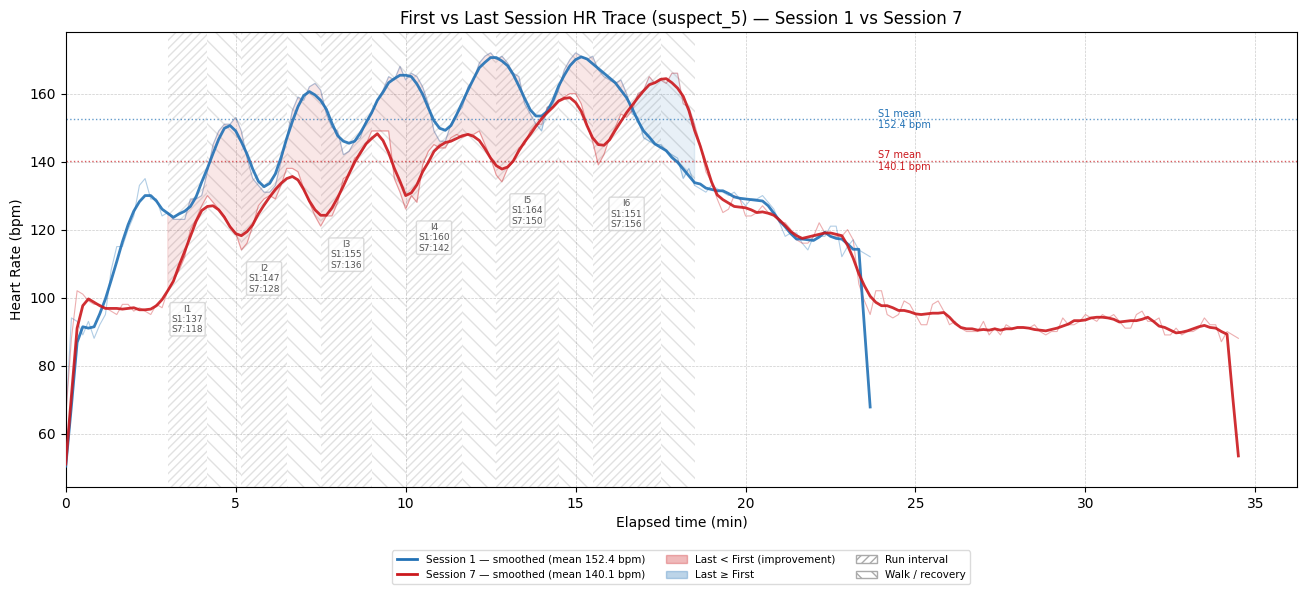

'Misalignment of runs. The first run starts one sprint earlier than the last run.'

In [266]:
# Suspect 5
plot_first_vs_last("../processed/suspect_5.json", run_start_sec=180, time_unit="minutes", rolling_window=5)

"Misalignment of runs. The first run starts one sprint earlier than the last run."

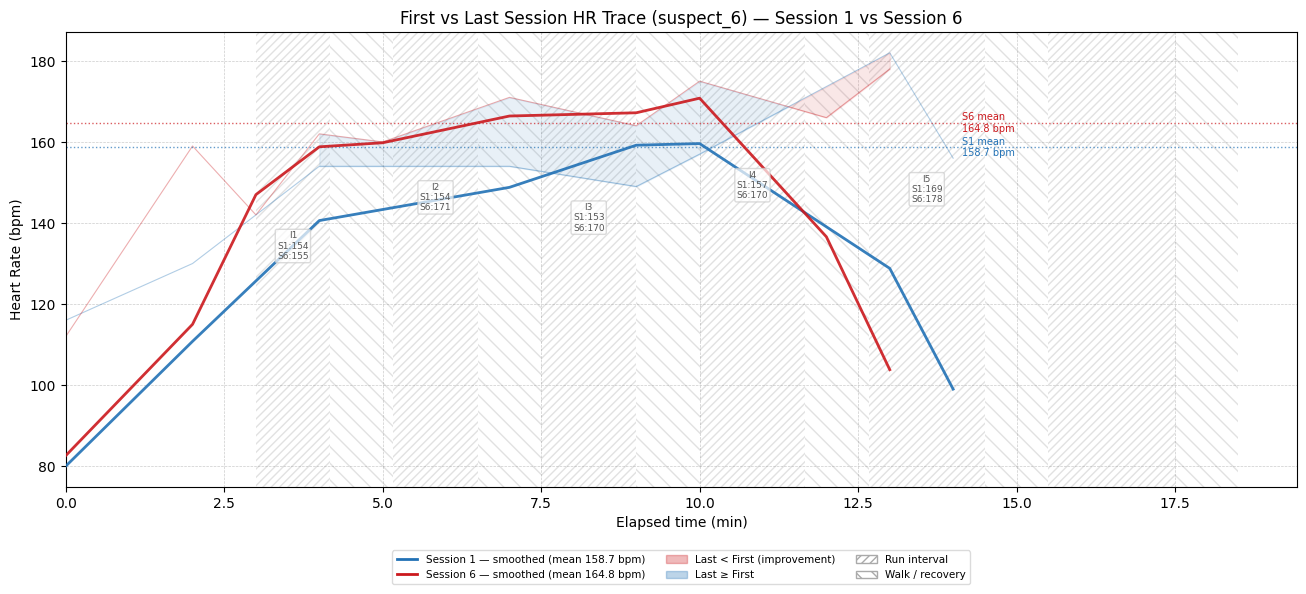

'Mega super random and flawed.'

In [267]:
# Suspect 6
plot_first_vs_last("../processed/suspect_6.json", run_start_sec=180, time_unit="minutes", rolling_window=5)

"Mega super random and flawed."

### Group Analysis

In [268]:
# TODO: t-tests including cohens d
# TODO: possibly include external factors, e.g. previous sports activity